In [17]:
# Cell 1: Setup and imports
import os

os.environ['KERAS_BACKEND'] = 'torch'  # You can change to 'jax' or 'torch' if preferred

import numpy as np
import keras
import sentencepiece as spm

print(f"Keras version: {keras.__version__}")
print(f"Keras backend: {keras.config.backend()}")

Keras version: 3.9.0
Keras backend: torch


Ladataan datasetti, käyttäen r eli read mode, jotta saadaan kaikki merkit oikein. Varmistetaan että käytetään utf-8 enkoodia, jotta saadaan kaikki merkit oikein. Säilytetään datasetti muuttujaan text.

In [18]:
# Cell 2: Load and prepare text data
# Load the Kalevala text
with open('../datasets/seitsemänveljestä.txt', 'r', encoding='utf-8-sig') as file:
    text = file.read()  #.lower()

print(f"Text length: {len(text)} characters")
print(f"First 100 characters: {text[:100]}")

Text length: 627004 characters
First 100 characters: ENSIMMÄINEN LUKU


Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella
rinteellä, liki


In [19]:
# Cell 3: Train SentencePiece model
# Save text to a temporary file for SentencePiece training
temp_file = 'seitsemanveljesta_temp.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    f.write(text)
    f.flush()
    os.fsync(f.fileno())

# Train SentencePiece model
vocab_size = 40000  # You can adjust this based on your needs
model_prefix = 'seitsemänveljestä_sp'

spm.SentencePieceTrainer.train(
    input=temp_file,
    model_prefix=model_prefix,
    vocab_size=vocab_size,
    character_coverage=1.0,  # Important for Finnish
    model_type='bpe',
    user_defined_symbols=['<PAD>', '<UNK>'],
)

# Load the trained tokenizer
sp = spm.SentencePieceProcessor()
sp.load(f"{model_prefix}.model")

# Test tokenization
test_text = "Huikea liuta. Tulispa sinusta oikein kukkomaakari"
tokens = sp.encode_as_pieces(test_text)
print(f"Tokenized example: {tokens}")
print(f"Vocabulary size: {sp.get_piece_size()}")

Tokenized example: ['▁Huikea', '▁liuta', '.', '▁Tulispa', '▁sinusta', '▁oikein', '▁kukkomaakari']
Vocabulary size: 40000


In [20]:
# Cell 4: Prepare training data
# Tokenize the text
seq_length = 64
pieces = sp.encode_as_ids(text)
print(f"Total tokens: {len(pieces)}")

# Create sequences
sequences = []
for i in range(0, len(pieces) - seq_length):
    # Input: first seq_length tokens, Target: next seq_length tokens (shifted by 1)
    sequences.append(pieces[i:i + seq_length + 1])

# Convert to NumPy arrays
sequences = np.array(sequences)
inputs = sequences[:, :-1]  # All tokens except the last one
targets = sequences[:, 1:]  # All tokens except the first one

print(f"Number of sequences: {len(sequences)}")
print(f"Input shape: {inputs.shape}")
print(f"Target shape: {targets.shape}")

# Split into training and validation sets
indices = np.arange(len(sequences))
np.random.shuffle(indices)

train_size = int(0.8 * len(sequences))
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_inputs, train_targets = inputs[train_indices], targets[train_indices]
val_inputs, val_targets = inputs[val_indices], targets[val_indices]

Total tokens: 103413
Number of sequences: 103349
Input shape: (103349, 64)
Target shape: (103349, 64)


In [21]:
# Cell 5: Define the model
def get_positional_encoding(max_len, d_model):
    """Create sinusoidal positional encoding."""
    positions = np.arange(max_len)[:, np.newaxis]
    angles = np.arange(d_model)[np.newaxis, :] / d_model
    angles = 1 / (10000 ** angles)

    pos_encoding = positions * angles
    pos_encoding[:, 0::2] = np.sin(pos_encoding[:, 0::2])
    pos_encoding[:, 1::2] = np.cos(pos_encoding[:, 1::2])

    return pos_encoding


# Define model parameters
embed_dim = 256
num_heads = 4
ff_dim = 512
num_layers = 3

# Create the model
inputs = keras.Input(shape=(seq_length,))
embedding_layer = keras.layers.Embedding(sp.get_piece_size(), embed_dim)(inputs)

# Add positional encoding
pos_encoding = get_positional_encoding(seq_length, embed_dim)
x = embedding_layer + pos_encoding


# Helper function to create causal attention mask
def create_causal_mask(size):
    """Create a causal attention mask to prevent looking at future tokens."""
    mask = 1 - np.triu(np.ones((size, size)), k=1)
    return mask  # Lower triangular matrix


# Transformer blocks
for _ in range(num_layers):
    # Multi-head attention with causal mask
    # Manually create causal mask since use_causal_mask parameter isn't available
    causal_mask = create_causal_mask(seq_length)

    # Apply attention with manual causal mask
    attention_output = keras.layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads
    )(x, x, attention_mask=causal_mask)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + attention_output)

    # Feed-forward network
    ffn = keras.Sequential([
        keras.layers.Dense(ff_dim, activation="relu"),
        keras.layers.Dense(embed_dim),
        keras.layers.Dropout(0.1)
    ])
    ffn_output = ffn(x)

    # Add & Norm
    x = keras.layers.LayerNormalization(epsilon=1e-6)(x + ffn_output)

# Final output layer
outputs = keras.layers.Dense(sp.get_piece_size())(x)

# Create model
model = keras.Model(inputs=inputs, outputs=outputs)

# Compile model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=3e-4),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 64)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 64, 256)   │ 10,240,000 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_7 (Add)         │ (None, 64, 256)   │          0 │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_2 (Cast)       │ (None, 64, 256)   │          0 │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cast_3 (Cast)       │ (None, 64, 256)   │          0 │ add_7[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ cast_2[0][0],     │
│ (MultiHeadAttentio… │                   │            │ cast_3[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_8 (Add)         │ (None, 64, 256)   │          0 │ add_7[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_8[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_3        │ (None, 64, 256)   │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_9 (Add)         │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_9[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_10 (Add)        │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_10[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sequential_4        │ (None, 64, 256)   │    262,912 │ layer_normalizat… │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_11 (Add)        │ (None, 64, 256)   │          0 │ layer_normalizat… │
│                     │                   │            │ sequential_4[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 64, 256)   │        512 │ add_11[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 64, 256)   │    263,168 │ layer_normalizat

 Total params: 22,101,312 (84.31 MB)

 Trainable params: 22,101,312 (84.31 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
# Cell 6: Train the model
batch_size = 64
epochs = 20

history = model.fit(
    train_inputs, train_targets,
    validation_data=(val_inputs, val_targets),
    batch_size=batch_size, 
    epochs=epochs,
    callbacks=[
        keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=1),
        keras.callbacks.ModelCheckpoint('seitsemänveljestä_model.keras', save_best_only=True)
    ]
)

Epoch 1/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 106s 82ms/step - accuracy: 0.0928 - loss: 7.7655 - val_accuracy: 0.2181 - val_loss: 5.5227 - learning_rate: 3.0000e-04
Epoch 2/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 109s 85ms/step - accuracy: 0.2876 - loss: 4.6771 - val_accuracy: 0.6989 - val_loss: 1.5836 - learning_rate: 3.0000e-04
Epoch 3/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 110s 85ms/step - accuracy: 0.7905 - loss: 1.1334 - val_accuracy: 0.9517 - val_loss: 0.2890 - learning_rate: 3.0000e-04
Epoch 4/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 108s 84ms/step - accuracy: 0.9547 - loss: 0.2697 - val_accuracy: 0.9657 - val_loss: 0.1887 - learning_rate: 3.0000e-04
Epoch 5/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 112s 87ms/step - accuracy: 0.9683 - loss: 0.1743 - val_accuracy: 0.9695 - val_loss: 0.1630 - learning_rate: 3.0000e-04
Epoch 6/20
1292/1292 ━━━━━━━━━━━━━━━━━━━━ 111s 86ms/step - accuracy: 0.9724 - loss: 0.1443 - val_accuracy: 0.9712 - val_loss: 0.1523 - learning_rate: 3.0000e-04
Epoch 7/20
1292/1292 ━━━━━━━━━━━━━

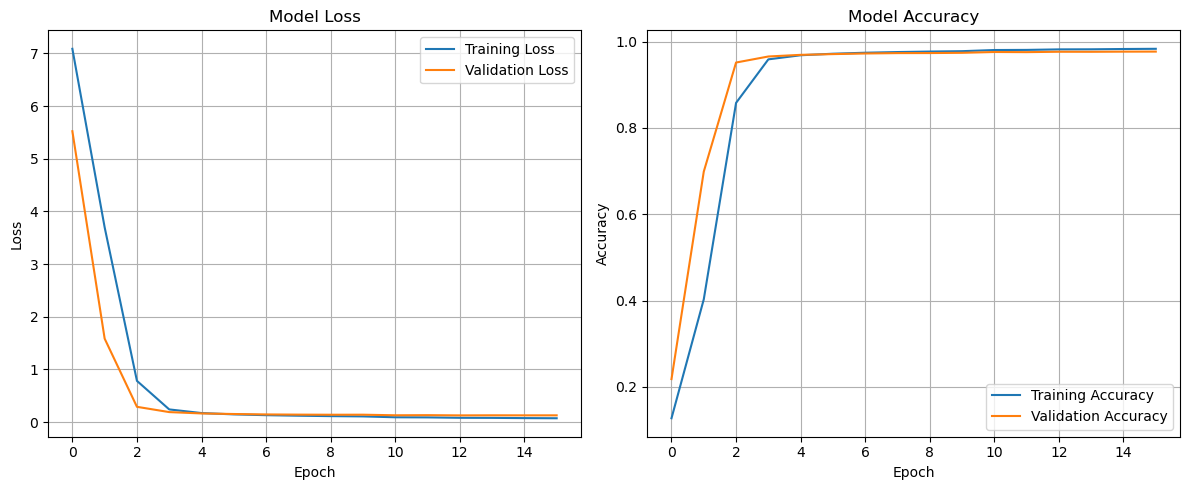

In [23]:
# Cell 7: Plot training metrics
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid()
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
# Cell 8: Save the model
model.save('seitsemänveljestä_model.keras')
print("Model saved as 'seitsemänveljestä_model.keras'")

Model saved as 'seitsemänveljestä_model.keras'


In [25]:
def generate_text(model, sp, prompt, num_tokens=100, temperature=1.0):
    """Generate text based on a prompt with proper lowercase handling."""
    # Convert prompt to lowercase to match training data
    lowercase_prompt = prompt  #.lower()

    # Encode the prompt
    input_ids = sp.encode_as_ids(lowercase_prompt)

    # Rest of your generation code stays the same...
    if len(input_ids) < seq_length:
        padding_length = seq_length - len(input_ids)
        input_ids = [0] * padding_length + input_ids
    else:
        padding_length = 0
        input_ids = input_ids[-seq_length:]

    # Generated tokens
    generated_ids = list(input_ids[padding_length:])

    # Generate text token by token
    for _ in range(num_tokens):
        x = np.array([input_ids])
        predictions = model.predict(x, verbose=0)[0]
        logits = predictions[-1]
        logits = logits / temperature
        exp_logits = np.exp(logits - np.max(logits))
        probs = exp_logits / np.sum(exp_logits)
        next_token = np.random.choice(len(probs), p=probs)
        generated_ids.append(next_token)
        input_ids = input_ids[1:] + [next_token]

    # Decode the generated sequence
    generated_text = sp.decode(generated_ids)

    return generated_text

In [37]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import torch

audio_file = "../datasets/whisper/testi2.wav"

def transcribe_audio_with_whisper(audio_array, sr=16000, model_size="large"):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model_name = f"openai/whisper-{model_size}"
    
    processor = WhisperProcessor.from_pretrained(model_name)
    model = WhisperForConditionalGeneration.from_pretrained(model_name).to(device)
    
    forced_decoder_ids = processor.get_decoder_prompt_ids(language="fi", task="transcribe")
    
    input_features = processor(
        audio_array, 
        sampling_rate=sr, 
        return_tensors="pt"
    ).input_features.to(device)
    
    with torch.no_grad():
        generated_ids = model.generate(
            input_features,
            forced_decoder_ids=forced_decoder_ids
        )
    
    transcription = processor.batch_decode(
        generated_ids, 
        skip_special_tokens=True
    )[0]
    
    return transcription


Testataan ensin tekstin generointi default parametreilla, eli 100 tokenia ja lämpötila 1.0.

In [ ]:
import librosa

# Cell 10: Generate sample text
prompts = [
    "Jukolan talo, eteläisessä Hämeessä, seisoo erään mäen pohjaisella rinteellä, liki Toukolan kylää."
]


def generate_text_for_prompts(prompts, num_tokens, temperature):
    for prompt in prompts:
        print(f"\nPrompt: {prompt}")
        generated = generate_text(model, sp, prompt, num_tokens, temperature)
        print(generated)

y, sr = librosa.load(audio_file, sr=16000)
# large model
transcription = transcribe_audio_with_whisper(y, sr)
generate_text_for_prompts(prompts=[transcription], num_tokens=100, temperature=1.0)

Muutetaan ensin lämpötilaa, mikä vaikuttaa tekstin satunnaisuuteen. Mitä pienempi lämpötila sitä loogisempaa teksti on, mutta myös vähemmän luovaa. Mitä suurempi lämpötila, sitä satunnaisempaa ja luovempaa teksti on, mutta myös vähemmän järkevää.

In [ ]:
transcription = transcribe_audio_with_whisper(y, sr, model_size="medium")
print(transcription)

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/494k [00:00<?, ?B/s]

normalizer.json:   0%|          | 0.00/52.7k [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/34.6k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.19k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.99k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.06G [00:00<?, ?B/s]

In [30]:
generate_text_for_prompts(prompts=[transcription], num_tokens=100, temperature=0.7)


Prompt:  Tämä on testiäänitys, samalla kun taustalla kuuluu puhetta ja tausta hälinää. Pystyykö tästä saavunut selvää?
Tämä on testiäänitys, samalla kun taustalla kuuluu puhetta ja tausta hälinää. Pystyykö tästä saavunut selvää? Sen tiedämme seisoivat veljekset, pisti he viimein toinen toisensa kurkkuihin ja rupesivat murkinalle, joka nyt tuntui heille makuisaksi. Kauan he atrioitsivat sanaakaan lausumatta, mutta lopulta nousi juttu tuosta jyrkeästä tapauksesta tiellä Tammiston ja Toukolan välillä. JUHANI. Aika saunan saimme totisesti; mutta ryöväreinä he karkasivat päällemme seipäillä ja karangoilla. Mutta ah! olisi meillä myös ollut aseet kourissa ja vaara silmissämme varoilla, niin sahattaisiinpa tänäpänä Toukolan kylässä arkunlautoja, ja haudankaivajalla olis työtä. Kissalan Aapelille annoin kuitenkin osansa. TUOMAS. Valkea, hiukseton linja juoksi hänen otsaltansa niskaan alas


Kuten ylhäältä näemme, lämpötilan laskeminen 0.2:een tekee tekstistä paljon järkevämpää ja vähemmän satunnaista. Tekstissä on kuitenkin paljon suoria kopioita alkuperäisestä tekstistä.

Seuraavaksi testataan korkealla lämpötilalla.

In [40]:
generate_text_for_prompts(prompts=prompts, num_tokens=100, temperature=2.0)


Prompt:  Stefanos, mistä saimmekaan puuta? Saimme puuta Samulin mökin takaa.
Stefanos, mistä saimmekaan puuta? Saimme puuta Samulin mökin takaa. EERO. Hän on pyynnissä, ankarassa ajossa, ja Möl tietäin hallan sudentarhan ojankoon ja padassa kaksi tammipöytyriä, kauhan, seitsemän lusikkaa ja muita huoneessa tarpeellisia kaluja, kertoili sisarensa pojille tarinoita ja merkillisiä juuritall kappale kehräjälintuu. Näin vähänpä taivaan kevät. Rapustaen astui hän teimme Pojat, pojat ymmärtää korpin Juo, jota entinen Jukolan vanhasta Iloisessa huimauksessayvämme kulki kaunista, kädetjestä alas, ja muistelivat tässä Lyökääs, kun tahdon nyt kuorsaa kuin mies; mutta maatkoon siellä hän ympärilleen mar' oltta Maija. SIMEONI. muistellessani nurkkia, potkii tämä


In [32]:
generate_text_for_prompts(prompts=[transcription], num_tokens=150, temperature=1.0)


Prompt:  Tämä on testiäänitys, samalla kun taustalla kuuluu puhetta ja tausta hälinää. Pystyykö tästä saavunut selvää?
Tämä on testiäänitys, samalla kun taustalla kuuluu puhetta ja tausta hälinää. Pystyykö tästä saavunut selvää? Sen eteläisellä puolella teki. Ja niinpä jyrkeä henki Impivaaran koulupöydän ääressä vallitsi kauan, kunnes aika, mennessä muutaman päivän, lievitti jälleen Eeron äkeän mielen ja muodon. Niin harrastelivat veljekset ehtiäkseen lukemisen taitoon, ja edistyikin heidän työnsä, vaikka alussa sangen vitkaa, varsinkin Timolta ja Juhanilta. KAHDESTOISTA LUKU Kesä tuli ja työ vainiolla alkoi. Veljekset milloin kyntelivät ja äjestelivät peltoansa, milloin raivasivat niittua korvessa ja milloin taasen rakentelivat uutta omettaansa kumisevalle aholle. Vaikeaksi tuntui heille alussa tämä raatamisen järjestys; mutta, pakoittaen luontoansa, taisivat he viimein täyttää kaikki arkiopäivät aamusta iltaan. Ja niin valmistui heidän omettansa, heidän peltonsa muuttui hienoksi mul

In [42]:
generate_text_for_prompts(prompts=[transcription], num_tokens=200, temperature=1.0)


Prompt:  Stefanos, mistä saimmekaan puuta? Saimme puuta Samulin mökin takaa.
Stefanos, mistä saimmekaan puuta? Saimme puuta Samulin mökin takaa. Hän astui pihalle, ja koska lähestyi hän illan tullessa vaikeni ja vaipui lepoon. Kuin hauta niin äänetön ja kylmä oli yö, ja pellon povella makasi harmaa halla, hengittäen kuoloa kylmää. Varhain seuraavana aamuna astuivat veljekset pirtistänsä ulos ja katselivat kauhistuen hävitystä vainiolla. Ja valkeana, lakastuneena kajasti pian äsken viherjöitsevä laiho. Tuumiskelivat miehet mitä nyt tehdä ja mihin keinoon ryhtyä, ja harkitsivat parhaaksi, raivaten ja kaivellen perinpohjin kuivata Sompiosuo, josta he tiesivät hallan nousevan heidän pelloillensa. Niin he päättivät, ja möyräilivät ja kaivelivat sumuisessa suossa, kuluessa kuuman kesän, nähden usein mieltä synkistävää nälkää. Oli silloin työpäivä raskas; väsyneinä käyskelivät he kotiansa vasta auringon laskiessa, ja tuskan ja vaivan musta juonne ympäröitsi vaisun miehen huulet. Mutta syksyn

In [33]:
generate_text_for_prompts(prompts=[transcription], num_tokens=50, temperature=1.0)


Prompt:  Tämä on testiäänitys, samalla kun taustalla kuuluu puhetta ja tausta hälinää. Pystyykö tästä saavunut selvää?
Tämä on testiäänitys, samalla kun taustalla kuuluu puhetta ja tausta hälinää. Pystyykö tästä saavunut selvää? Sen tiedämme seisoivat veljekset, kolmen päivän kuluttua Eeron äkeä mieli oli vähän lievinnyt, antoi hän muristen ilmi kuinka Simeonin laita oli heidän palatessaan kaupungista. Olipa hän useinkin haastellut joistakin pienistä, tuumankorkeista äijistä, jotka, niinkuin hän lausuili, parveilivat tuhansittain hänen ympärillään. Niin kertoili


Nyt teksti alkaa olla jo epäloogista, eikä siitä löydy juurikaan järkeviä virkkeitä.

In [34]:
generate_text_for_prompts(prompts=[transcription], num_tokens=160, temperature=0.7)


Prompt:  Tämä on testiäänitys, samalla kun taustalla kuuluu puhetta ja tausta hälinää. Pystyykö tästä saavunut selvää?
Tämä on testiäänitys, samalla kun taustalla kuuluu puhetta ja tausta hälinää. Pystyykö tästä saavunut selvää? Sen tiedämme seisoivat veljekset, josta iloinen joukko sekä miesten että naisten toiminnoissa. Hänenpä suustansa kaikui kerran lause, joka vieläkin eleskelee naurettavana kansan huulilla Jukolan ja Toukolan tienoilla. Eräänä päivänä, koska hän havutukin ääressä veisteli pienellä veistinkirveellänsä leipälapiota Venlalle ja väki atrioitsi, harjallinen pöytyri sianmurennusta edessään, muistutti hän kaikkia yhteisesti: »kun panee hyvin pikkuisen sianmurennusta leivän päälle, niin se särvittää niin». Lausui hän niin, ja tuostapa pyrskähtivät nauruun sekä miehet että naiset, ja Juhani itse, myös naurettuaan hieman, katsoi parhaaksi vähän nuhdella veljeänsä liiasta ahneudesta. Mutta lausuipa tuohon Simeoni taasen: »kohtuullisuuteenhan minä teitä kehoitan, varoitan t

In [ ]:
# Cell 11: Load model (if you're starting a new session)
# Uncomment these lines to load a previously saved model
"""
# Load saved model
model = keras.models.load_model('kalevala_model.keras')

# Load SentencePiece tokenizer
sp = spm.SentencePieceProcessor()
sp.load('kalevala_sp.model')

# Test generation
prompt = "Mieleni minun tekevi"
generated = generate_text(model, sp, prompt, num_tokens=150, temperature=1.0)
print(generated)
"""